# Calculating Air Quality Index (AQI)

Air Quality Index (AQI) is a **unit less number** useful for effective communication of air quality status to people.

It unifies all the complicated (a) science of pollution composition, (b) exposure rate based health severity, (c) ambient standards, and (d) measurement and standard protocols, into simple color coded alerts of good or bad or severe air pollution categories.

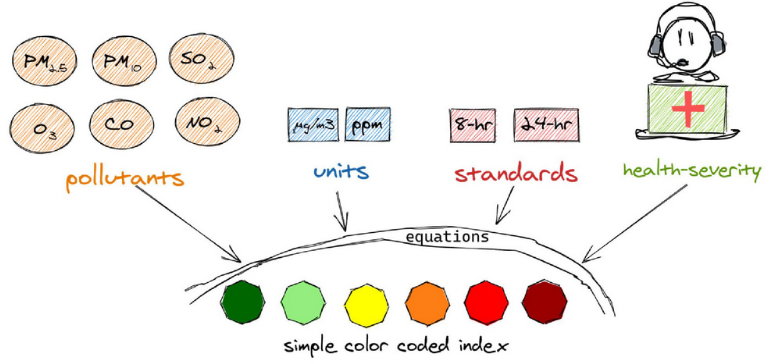

It is calculated differently in different countries. In this tutorial, we will calculate AQI in the [Indian method](https://cpcb.nic.in/displaypdf.php?id=bmF0aW9uYWwtYWlyLXF1YWxpdHktaW5kZXgvSG93X0FRSV9DYWxjdWxhdGVkLnBkZg==).

In India, eight pollutants (PM10, PM2.5, NO2, O3, CO, SO2, NH3 and Pb) are generally monitored at each monitoring station. Each pollutant will get a **sub-index**. The AQI is the worst sub-index of the eight sub-indices calculated. A station may not monitor all the eight pollutants. For AQI to be calculated at a station:

1. A minimum of 3 pollutants should be monitored (with PM2.5 or PM10 being one of them), and

2. Each pollutant should be monitored for a minimum of 16 hours.

For more reading on AQI, refer: [10 Frequently asked questions on AQI](https://urbanemissions.info/wp-content/uploads/docs/SIM-46-2021.pdf)<br>
To know more about the pollutants mentioned above, refer: [Know Your Pollutants](https://urbanemissions.info/wp-content/uploads/docs/Primer-Know-Your-Pollutants.pdf)

## Calculating Sub-Index of a pollutant

The sub-index is also a unit less number. The Central Pollution Pollution Board (CPCB) in India mapped pollutant concentration breakpoints to certain air quality categories as follows:

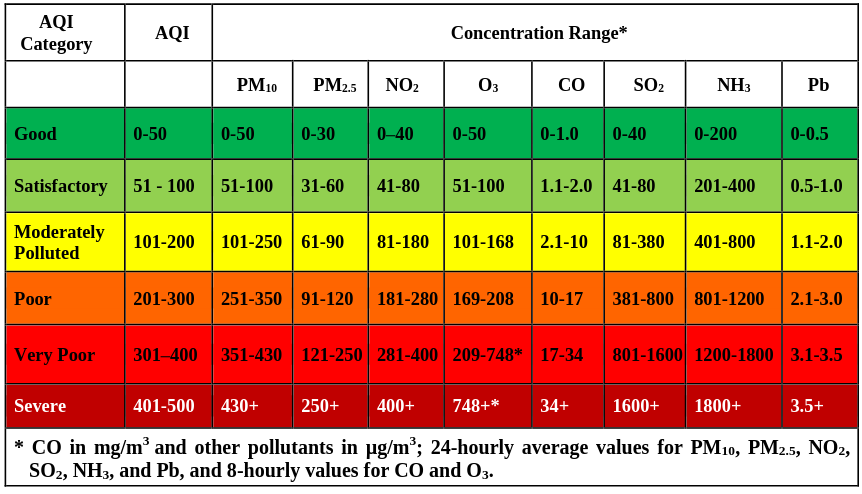

These breakpoints are different in other countries. The AQI value would thus change even with the same concentration data in different countries.

In [2]:
#| code-fold: true
#| code-summary: "Show hidden code that articulates CPCB breakpoints into a Python dictionary"

# CPCB AQI Breakpoints: {pollutant: [(BPlow, BPhigh, Ilow, Ihigh), ...]}
# Concentrations are in µg/m³ except CO (mg/m³) and NH3 (µg/m³)
CPCB_BREAKPOINTS = {
    "PM2.5": [  # 24-hr avg, µg/m³
        (0.0,   30.0,   0,   50),
        (30,  60.0,  50,  100),
        (60,  90.0, 100,  200),
        (90, 120.0, 200,  300),
        (120,250.0, 300,  400),
        (250,500.0, 400,  500),
    ],
    "PM10": [  # 24-hr avg, µg/m³
        (0,    50,   0,   50),
        (50,  100,  50,  100),
        (100, 250, 100,  200),
        (250, 350, 200,  300),
        (350, 430, 300,  400),
        (430, 600, 400,  500),
    ],
    "NO2": [  # 24-hr avg, µg/m³
        (0,    40,   0,   50),
        (40,   80,  50,  100),
        (80,  180, 100,  200),
        (180, 280, 200,  300),
        (280, 400, 300,  400),
        (400, 800, 400,  500),
    ],
    "O3": [  # 8-hr avg, µg/m³
        (0,    50,   0,   50),
        (50,  100,  50,  100),
        (100, 168, 100,  200),
        (168, 208, 200,  300),
        (208, 748, 300,  400),
        (748,1000, 400,  500),
    ],
    "CO": [  # 8-hr avg, mg/m³
        (0.0,  1.0,   0,   50),
        (1.0,  2.0,  50,  100),
        (2.0,  10.0,100,  200),
        (10.0, 17.0,200,  300),
        (17.0, 34.0,300,  400),
        (34.0, 50.0,400,  500),
    ],
    "SO2": [  # 24-hr avg, µg/m³
        (0,    40,   0,   50),
        (40,   80,  50,  100),
        (80,  380, 100,  200),
        (380, 800, 200,  300),
        (800,1600, 300,  400),
        (1600,2620,400,  500),
    ],
    "NH3": [  # 24-hr avg, µg/m³
        (0,    200,   0,   50),
        (200,  400,  50,  100),
        (400,  800, 100,  200),
        (800, 1200, 200,  300),
        (1200,1800, 300,  400),
        (1800,2400, 400,  500),
    ],
    "Pb": [  # 24-hr avg, µg/m³
        (0.0,  0.5,   0,   50),
        (0.5,  1.0,  50,  100),
        (1.0,  2.0, 100,  200),
        (2.0,  3.0, 200,  300),
        (3.0,  3.5, 300,  400),
        (3.5,  5.0, 400,  500),
    ],
}

For instance, if the 24-hourly average of PM2.5 is 30 μg/m3, the sub-index of PM2.5 would be 50. if PM2.5 is 121 μg/m3, sub-index would be 301.

To calculate the sub-index for other intermediary values of pollutant concentration, we use linear segmentation.

$$I_p = \frac{I_{Hi} - I_{Lo}}{BP_{Hi} - BP_{Lo}} ~ (C_p - BP_{Lo}) + I_{Lo}$$

1. Ip is the sub index for pollutant p
2. Cp is the concentration of pollutant p
3. BP (Hi and Lo) are the breakpoints greater and lesser than Cp respectively
4. I (Hi and Lo) are the AQI values corresponding to BP (Hi and Lo) respectively

We'll write a pythonic function to calculate sub-index of a pollutant from its concentration value.

In [3]:
#| code-fold: true
#| code-summary: "Show hidden code"

def calculate_sub_index(pollutant: str, concentration: float) -> dict:
    """
    Calculate the CPCB AQI sub-index for a given pollutant and concentration.

    Args:
        pollutant    : Pollutant name. Supported: PM2.5, PM10, NO2, O3, CO, SO2, NH3, Pb
                       (case-insensitive)
        concentration: Measured concentration value.
                       Units — µg/m³ for all except CO; mg/m³ for CO

    Returns:
        A dict with keys:
            pollutant     : Normalised pollutant name
            concentration : Input concentration
            sub_index     : Computed AQI sub-index (int), or None if out of range

    Formula (linear interpolation per CPCB):
        Ip = [(IHi - ILo) / (BPHi - BPLo)] * (Cp - BPLo) + ILo
    """
    result = {
        "pollutant": pollutant,
        "concentration": concentration,
        "sub_index": None,
        "error": None,
    }

    # Normalise pollutant name
    normalised = pollutant.strip().upper().replace(".", "")
    name_map = {p.upper().replace(".", ""): p for p in CPCB_BREAKPOINTS}

    if normalised not in name_map:
        result["error"] = (
            f"Unknown pollutant '{pollutant}'. "
            f"Supported: {', '.join(CPCB_BREAKPOINTS.keys())}"
        )
        return result

    pollutant_key = name_map[normalised]
    result["pollutant"] = pollutant_key
    breakpoints = CPCB_BREAKPOINTS[pollutant_key]

    if concentration < 0:
        result["error"] = "Concentration cannot be negative."
        return result

    # Find the matching breakpoint segment
    for bp_lo, bp_hi, i_lo, i_hi in breakpoints:
        if bp_lo <= concentration <= bp_hi:
            # CPCB linear interpolation formula
            sub_index = ((i_hi - i_lo) / (bp_hi - bp_lo)) * (concentration - bp_lo) + i_lo
            sub_index = round(sub_index)
            result["sub_index"] = sub_index
        elif concentration > bp_hi:
            sub_index = 500
            result["sub_index"] = sub_index

    return result

In [4]:
calculate_sub_index(pollutant='pm2.5', concentration=35)

{'pollutant': 'PM2.5', 'concentration': 35, 'sub_index': 58, 'error': None}

## Exercise: Calculating Sub-Indices of various pollutants from real data of a monitoring station

For the purposes of this tutorial, we'll use concentration data of from a single monitor in Puducherry. This data can be downloaded from [openaq](https://explore.openaq.org/locations/60659) OR from [CPCB's Data Repository](https://airquality.cpcb.gov.in/ccr/#/caaqm-dashboard-all/caaqm-landing/caaqm-data-repository) We'll calculate sub-indices of all pollutants for a day.

In [25]:
import pandas as pd
pollutant_conc = pd.read_csv('data/openaq_location_60659_measurments.csv')
pollutant_conc['datetimeLocal'] = pd.to_datetime(pollutant_conc['datetimeLocal']) #Convert to datetime format
pollutant_conc.head(5)

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,60659,"Jawahar Nagar, Puducherry - PPCC",co,0.71,ppb,2026-03-01T00:15:00Z,2026-03-01 05:45:00+05:30,Asia/Kolkata,11.9309,79.8027,NaN,NaN,NaN,Puducherry Pollution Control Committee,CPCB
1,60659,"Jawahar Nagar, Puducherry - PPCC",co,0.77,ppb,2026-03-01T00:30:00Z,2026-03-01 06:00:00+05:30,Asia/Kolkata,11.9309,79.8027,NaN,NaN,NaN,Puducherry Pollution Control Committee,CPCB
2,60659,"Jawahar Nagar, Puducherry - PPCC",co,0.80,ppb,2026-03-01T00:45:00Z,2026-03-01 06:15:00+05:30,Asia/Kolkata,11.9309,79.8027,NaN,NaN,NaN,Puducherry Pollution Control Committee,CPCB
3,60659,"Jawahar Nagar, Puducherry - PPCC",co,0.78,ppb,2026-03-01T01:00:00Z,2026-03-01 06:30:00+05:30,Asia/Kolkata,11.9309,79.8027,NaN,NaN,NaN,Puducherry Pollution Control Committee,CPCB
4,60659,"Jawahar Nagar, Puducherry - PPCC",co,0.80,ppb,2026-03-01T01:15:00Z,2026-03-01 06:45:00+05:30,Asia/Kolkata,11.9309,79.8027,NaN,NaN,NaN,Puducherry Pollution Control Committee,CPCB


Data is available at 15 minute frequency. We learnt that sub-indices require 24-hourly average (8-hourly for O3 and CO). Hence, to calculate the sub-index at 4PM on March 2nd, we'd need average of the previous 24 hours.

In [56]:
start = pd.Timestamp('2026-03-01 16:00:00', tz='Asia/Kolkata')
end   = pd.Timestamp('2026-03-02 16:00:00', tz='Asia/Kolkata')

pollutant_conc_24h = pollutant_conc[pollutant_conc['datetimeLocal'].between(start, end)]

Now we have data of 24 hours before March 2nd 4PM. Before we calculate 24-hourly averages, we have to ensure if we have atleast 16 hours of data for each pollutant to calculate the sub-index.

In [57]:
pollutant_conc_24h.groupby('parameter').value.count()/4

parameter
co                  20.25
no                  20.00
no2                 20.00
nox                 20.00
o3                  19.50
pm10                19.75
pm25                20.00
relativehumidity    20.50
so2                 16.50
temperature         20.50
wind_direction      20.50
wind_speed          20.50
Name: value, dtype: float64

We have atleast 16 hours of data for each pollutant. We can see that NH3, PB are not monitored at this station. The units of pollutant concentration are also different:

In [58]:
aqi_monitoring_pollutants = ['pm10', 'pm25', 'no2', 'o3', 'co', 'so2', 'nh3', 'pb']
pollutant_conc_24h = pollutant_conc_24h[pollutant_conc_24h.parameter.isin(aqi_monitoring_pollutants)]
pollutant_conc_24h.groupby('parameter').unit.unique()

parameter
co        [ppb]
no2       [ppb]
o3      [µg/m³]
pm10    [µg/m³]
pm25    [µg/m³]
so2       [ppb]
Name: unit, dtype: object

We'll take help of the following table to convert all pollutant concentrations to µg/m3
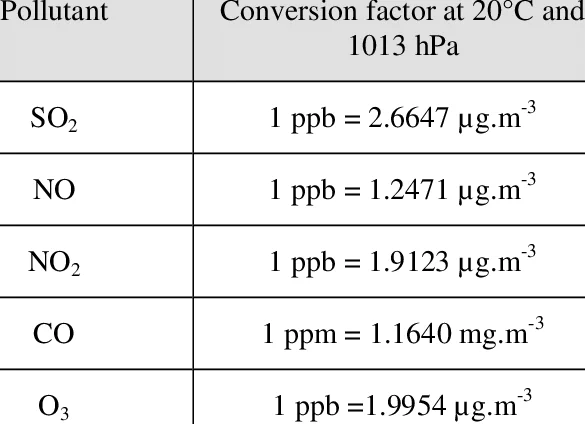

In [59]:
pollutant_conc_24h_pivoted = pollutant_conc_24h.pivot_table('value','datetimeLocal','parameter')
pollutant_conc_24h_pivoted['so2'] = pollutant_conc_24h_pivoted['so2']*2.66
pollutant_conc_24h_pivoted['no2'] = pollutant_conc_24h_pivoted['no2']*1.91

pollutant_conc_24h_pivoted['co'] = pollutant_conc_24h_pivoted['co']*1.16 #CO units should be in mg/m3

In [60]:
pollutant_conc_24h_pivoted

parameter,co,no2,o3,pm10,pm25,so2
datetimeLocal,,,,,,
2026-03-01 16:00:00+05:30,0.3944,8.977,72.3,73.0,50.0,NaN
2026-03-01 16:15:00+05:30,0.4292,9.168,71.0,73.0,50.0,15.428
2026-03-01 16:30:00+05:30,0.3944,9.932,71.1,73.0,50.0,16.758
2026-03-01 16:45:00+05:30,0.2668,10.123,73.3,71.0,53.0,21.014
2026-03-01 17:15:00+05:30,0.2436,10.123,74.1,71.0,53.0,23.674
...,...,...,...,...,...,...
2026-03-02 14:45:00+05:30,0.4524,10.314,81.5,63.0,47.0,14.630
2026-03-02 15:00:00+05:30,0.4640,9.932,80.2,63.0,47.0,17.556
2026-03-02 15:15:00+05:30,0.4756,9.932,80.9,63.0,47.0,16.758


For all pollutants except CO and O3, we can now simply calculate a 24 hour average.

In [61]:
average = pollutant_conc_24h_pivoted[['no2','so2','pm25','pm10']].mean()
average

parameter
no2     22.962975
so2     17.830061
pm25    59.212500
pm10    81.683544
dtype: float64

For O3 and CO, 8-hourly average is required. Since there can be multiple 8 hour windows over a day, we consider the maximum of rolling 8 hour averages.

In [62]:
o3_co_avg = pollutant_conc_24h_pivoted[['o3','co']].rolling('8h',
                                                min_periods=24 #Minimum of 6hours data to calculate 8 hour average (
                                               ).mean().max() 
o3_co_avg

parameter
o3    72.407407
co     1.028224
dtype: float64

In [63]:
average_df_final = pd.DataFrame(pd.concat([average,o3_co_avg])).reset_index()
average_df_final.columns = ['pollutant','average']
average_df_final

,pollutant,average
0,no2,22.962975
1,so2,17.830061
2,pm25,59.212500
3,pm10,81.683544
4,o3,72.407407
5,co,1.028224


Now we will use the function we created to calculate the sub-index of each pollutant. We will apply `calculate_sub_index` function on each row in the above daily average concentrations.

In [64]:
average_df_final['sub-index'] = average_df_final.apply(lambda x: calculate_sub_index(x['pollutant'], x['average'])['sub_index'], axis=1)
average_df_final

,pollutant,average,sub-index
0,no2,22.962975,29
1,so2,17.830061,22
2,pm25,59.212500,99
3,pm10,81.683544,82
4,o3,72.407407,72
5,co,1.028224,51


The final AQI at this monitoring station is the maximum of all the sub-indices. And the pollutant that has the maximum sub-index is the prominent pollutant driving the AQI.

In [65]:
AQI = average_df_final['sub-index'].max()
prominent_pollutant = average_df_final.loc[average_df_final['sub-index'].idxmax(), 'pollutant'].upper()
print(f'The AQI at Jawahar Nagar, Puducherry on March 2nd 4PM is: {AQI}. \n The prominent pollutant is {prominent_pollutant}')

The AQI at Jawahar Nagar, Puducherry on March 2nd 4PM is: 99. 
 The prominent pollutant is PM25


The [official AQI Bulletin of March 2nd](https://cpcb.nic.in/displaypdf.php?id=RG93bmxvYWRzL0FRSV9CdWxsZXRpbl8yMDI2MDMwMi5wZGY=) reported that the `Puducherry's AQI is 101`, with `PM2.5` as prominent pollutant. The minor discrepancy could be because of any data gaps. Since Puducherry has only one monitor, it's AQI value is reported as city average.

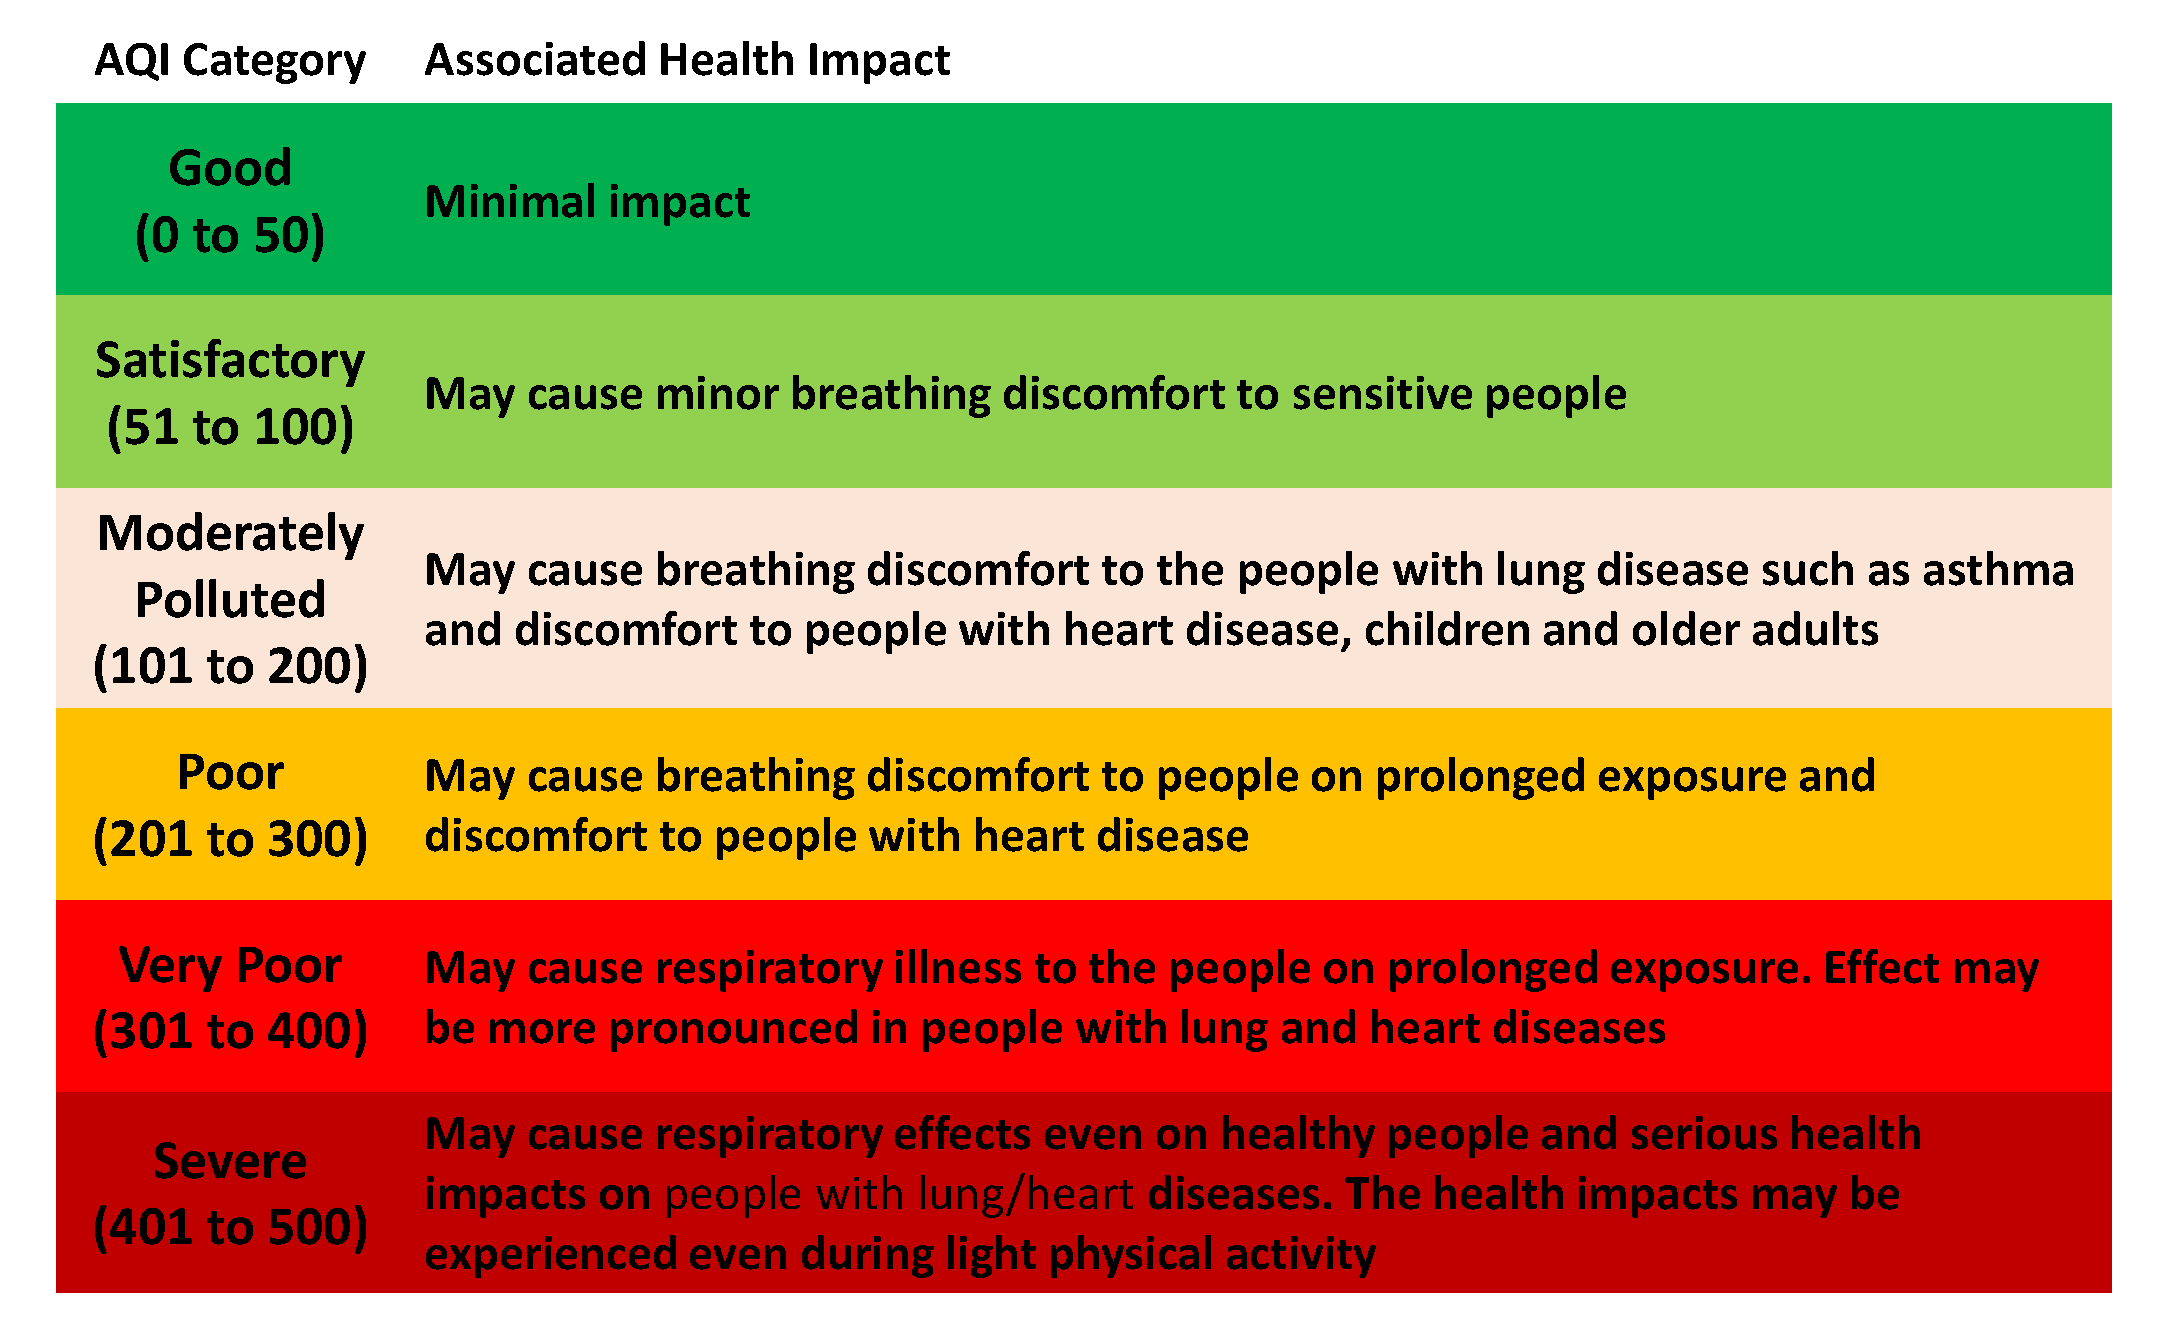

## Summary

We thus learnt how to calculate AQI at a station using the 24 hour average concentrations of each pollutant. CPCB calculates AQI at every station at 4PM and publishes the average AQI of all stations in a city in its [AQI Bulletins](https://cpcb.nic.in/AQI_Bulletin.php). UrbanEmissions cleaned this AQI Bulletins data from 2015-2025. You can check it out here: [AQI Bulletins Visualisation](https://urbanemissionsinfo.github.io/AQI_bulletins/)

The real-time AQI that we see on portals like [CPCB - NAQI](https://airquality.cpcb.gov.in/AQI_India/) perform the same operation for every station, every hour.

It should be noted that different portals use different formulae to calculate the AQI. These are not comparable with each other. <br>
1. [IQAir](https://www.iqair.com/in-en/india/delhi/delhi) developed a [AQI+](https://www.iqair.com/in-en/newsroom/how-is-aqi-calculated-without-all-6-key-pollutants) algorithm.<br>
2. [AQICN](https://aqicn.org/station/india/hyderabad/zoo-park--bahadurpura-west/) uses the [NowCast](https://aqicn.org/faq/2015-03-15/air-quality-nowcast-a-beginners-guide/) algorithm to calculate AQI.

